# Analizar Modelo B (heatmaps)

Este notebook carga el modelo ya entrenado (`modelo_b_mejor.pth`), corre inferencia sobre
imagenes de `frames_val/`, y compara la prediccion contra el ground truth del CSV.

**Por que un notebook y no el script:** acá podemos mirar resultados intermedios (las imagenes
de heatmaps, el esqueleto dibujado) sin tener que volver a correr el entrenamiento. El script
(`entrenar_modelo_b.py`) sigue siendo lo que usás para entrenar de verdad; este notebook es solo
para inspeccionar el resultado.

Ejecutá las celdas en orden (Shift+Enter).

## 1. Imports y configuración

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# --- mismas constantes que entrenar_modelo_b.py, deben coincidir siempre ---
KP_NAMES = [
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
    "head", "neck"
]
N_KP = len(KP_NAMES)
HM_SIZE = 64

SKELETON = [
    (12, 13), (13, 0), (13, 1),
    (0, 2), (2, 4), (1, 3), (3, 5),
    (0, 6), (1, 7),
    (6, 8), (8, 10), (7, 9), (9, 11),
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cpu


## 2. La arquitectura del Modelo B, explicada

Esta es **la misma clase exacta** que está en `entrenar_modelo_b.py` (la copiamos acá para no
tener que importar el script). La idea de fondo:

```
Imagen 224x224x3
   │
   ▼
ENCODER (MobileNetV2.features)        ← "ve" la imagen, preentrenado en ImageNet
   │  reduce resolucion, aumenta canales
   ▼
Mapa de features (1280, 7, 7)         ← todavia tiene estructura espacial 2D
   │
   ▼
DECODER (ConvTranspose2d x3)          ← agranda la resolucion de vuelta
   │  7x7 → 14x14 → 28x28 → 56x56
   ▼
Conv2d final (64 → 14 canales)        ← un canal por keypoint
   │
   ▼
interpolate a 64x64                   ← tamaño final del heatmap
   │
   ▼
14 heatmaps de 64x64                  ← cada uno: "donde esta este keypoint"
```

Cada uno de los 14 heatmaps es un mapa de "calor": el pixel mas brillante (mas cercano a 1)
es donde el modelo cree que esta ese keypoint especifico.

In [11]:
class PoseModelB(nn.Module):
    def __init__(self, n_keypoints=14):
        super().__init__()
        # weights=None: no bajamos pesos de ImageNet de nuevo, los vamos a
        # cargar desde el .pth que ya entrenamos
        backbone = models.mobilenet_v2(weights=None)
        self.encoder = backbone.features  # salida: (B, 1280, 7, 7)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(1280, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, n_keypoints, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        x = F.interpolate(x, size=(HM_SIZE, HM_SIZE), mode='bilinear', align_corners=False)
        return x

print("Clase PoseModelB definida.")

Clase PoseModelB definida.


## 3. Cargar el modelo entrenado

In [12]:
# ajustá la ruta si tu .pth quedó en otro lado
RUTA_MODELO = "modelo_b_fix_mejor.pth"

modelo = PoseModelB(n_keypoints=N_KP).to(device)
modelo.load_state_dict(torch.load(RUTA_MODELO, map_location=device))
modelo.eval()  # modo evaluacion: desactiva dropout/BN-update

n_params = sum(p.numel() for p in modelo.parameters())
n_params_encoder = sum(p.numel() for p in modelo.encoder.parameters())
n_params_decoder = sum(p.numel() for p in modelo.decoder.parameters())
print(f"Modelo cargado desde {RUTA_MODELO}")
print(f"Parametros totales:  {n_params:,}")
print(f"  Encoder (MobileNetV2): {n_params_encoder:,}")
print(f"  Decoder:                {n_params_decoder:,}")

Modelo cargado desde modelo_b_fix_mejor.pth
Parametros totales:  8,124,366
  Encoder (MobileNetV2): 2,223,872
  Decoder:                5,900,494


## 4. Cargar el CSV de validación y elegir imágenes para inspeccionar

In [13]:
CSV_PATH = "val_14kp.csv"
FRAMES_DIR = "frames_val"

df = pd.read_csv(CSV_PATH)
print(f"{len(df)} filas en {CSV_PATH}")
df.head(3)

7074 filas en val_14kp.csv


,imagen,left_shoulder_x,left_shoulder_y,right_shoulder_x,right_shoulder_y,left_elbow_x,left_elbow_y,right_elbow_x,right_elbow_y,left_wrist_x,...,right_knee_x,right_knee_y,left_ankle_x,left_ankle_y,right_ankle_x,right_ankle_y,head_x,head_y,neck_x,neck_y
0,114203_165388.jpg,0.904110,0.234392,0.613014,0.219058,0.888699,0.300110,0.500000,0.277108,0.835616,...,0.508562,0.466594,0.794521,0.899233,0.323630,0.556407,0.695205,0.115005,0.753425,0.214677
1,114203_181177.jpg,0.504286,0.254016,0.244286,0.293173,0.638571,0.357430,0.132857,0.364458,0.652857,...,0.328571,0.758032,0.741429,0.802209,0.337143,0.906627,0.371429,0.108434,0.361429,0.238956
2,114203_183967.jpg,0.967213,0.234858,0.511475,0.234858,0.947541,0.362176,0.373770,0.362176,1.108197,...,0.567213,0.673671,0.747541,0.840544,0.606557,0.828183,0.452459,0.189122,0.783607,0.164400


In [14]:
# mismo transform que usa entrenar_modelo_b.py para val (sin augmentation)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])


def predecir(idx):
    """Corre el modelo sobre la fila idx del df. Devuelve imagen original (PIL),
    heatmaps predichos (14,64,64) y coordenadas de ground truth normalizadas."""
    row = df.iloc[idx]
    path = os.path.join(FRAMES_DIR, row["imagen"])
    img = Image.open(path).convert("RGB")

    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        heatmaps = modelo(tensor)[0].cpu().numpy()  # (14, 64, 64)

    gt = {}
    for kp in KP_NAMES:
        gt[kp] = (row[f"{kp}_x"], row[f"{kp}_y"])

    return img, heatmaps, gt, row["imagen"]


print("Funcion predecir() lista.")

Funcion predecir() lista.


## 5. Visualizar: heatmap predicho vs ground truth, sobre la imagen

Para cada keypoint:
- **Punto verde** = donde el modelo predijo (pico del heatmap)
- **Punto rojo** = donde está realmente (ground truth del CSV)
- Cuanto más cerca estén verde y rojo, mejor predijo el modelo ese punto.

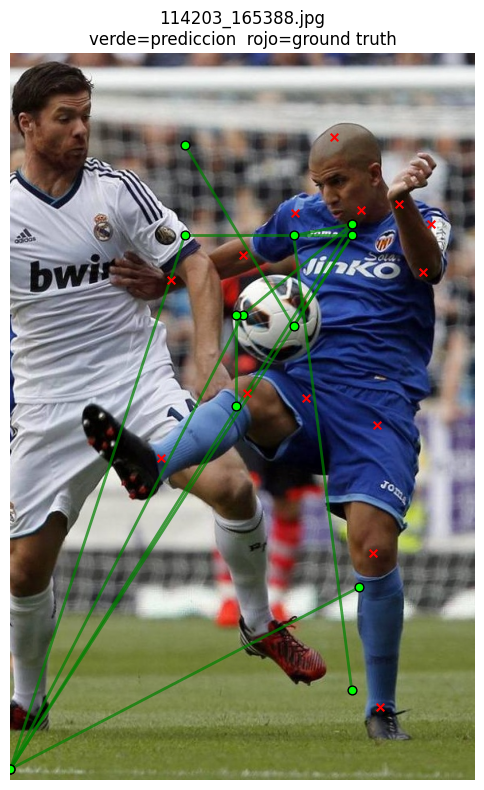

Error promedio: 320.1 px sobre 14 keypoints (imagen de 584x913)


In [15]:
def heatmaps_a_coords(heatmaps, umbral=0.1):
    """Extrae la coordenada normalizada (x,y) del pico de cada heatmap.
    Si el pico es muy bajo, se considera que el modelo no encontro ese keypoint."""
    coords = {}
    for i, kp in enumerate(KP_NAMES):
        hm = heatmaps[i]
        conf = float(hm.max())
        if conf < umbral:
            coords[kp] = (None, None, conf)
        else:
            idx = hm.argmax()
            y = (idx // HM_SIZE) / HM_SIZE
            x = (idx % HM_SIZE) / HM_SIZE
            coords[kp] = (x, y, conf)
    return coords


def graficar_comparacion(idx):
    img, heatmaps, gt, nombre = predecir(idx)
    pred = heatmaps_a_coords(heatmaps)
    w, h = img.size

    fig, ax = plt.subplots(1, 1, figsize=(6, 8))
    ax.imshow(img)
    ax.set_title(f"{nombre}\nverde=prediccion  rojo=ground truth")

    # esqueleto predicho (verde)
    pts_pred = {}
    for kp in KP_NAMES:
        x, y, conf = pred[kp]
        if x is not None:
            pts_pred[kp] = (x * w, y * h)

    for a, b in SKELETON:
        ka, kb = KP_NAMES[a], KP_NAMES[b]
        if ka in pts_pred and kb in pts_pred:
            xa, ya = pts_pred[ka]
            xb, yb = pts_pred[kb]
            ax.plot([xa, xb], [ya, yb], 'g-', linewidth=2, alpha=0.7)

    for kp, (x, y) in pts_pred.items():
        ax.scatter(x, y, c='lime', s=40, edgecolors='black', zorder=5)

    # ground truth (rojo)
    for kp, (gx, gy) in gt.items():
        if 0.0 <= gx <= 1.0 and 0.0 <= gy <= 1.0:
            ax.scatter(gx * w, gy * h, c='red', s=30, marker='x', zorder=6)

    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # error promedio en pixeles, solo sobre keypoints donde hay ambos
    errores = []
    for kp in KP_NAMES:
        px, py, conf = pred[kp]
        gx, gy = gt[kp]
        if px is not None and 0.0 <= gx <= 1.0:
            err = np.sqrt(((px - gx) * w) ** 2 + ((py - gy) * h) ** 2)
            errores.append(err)
    if errores:
        print(f"Error promedio: {np.mean(errores):.1f} px sobre {len(errores)} keypoints "
              f"(imagen de {w}x{h})")


# probá con distintos indices para ver varios ejemplos
graficar_comparacion(0)

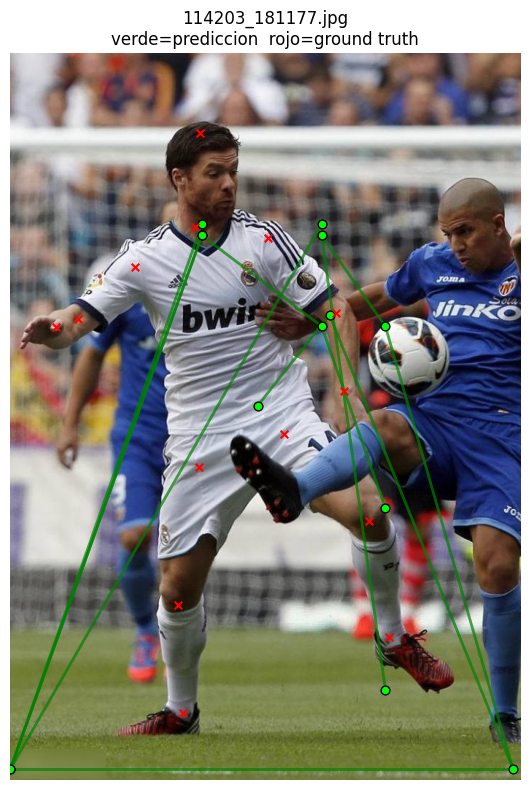

Error promedio: 346.7 px sobre 14 keypoints (imagen de 700x996)


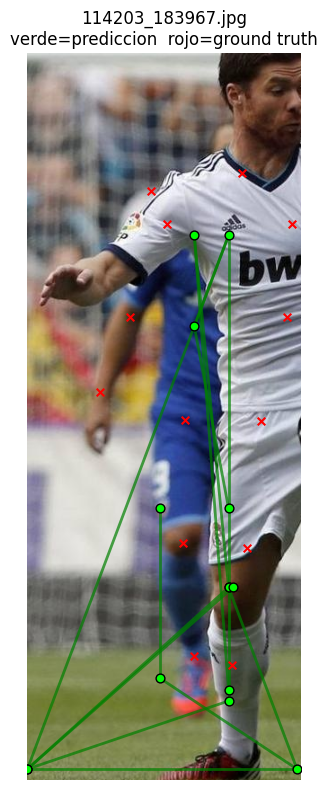

Error promedio: 292.2 px sobre 13 keypoints (imagen de 305x809)


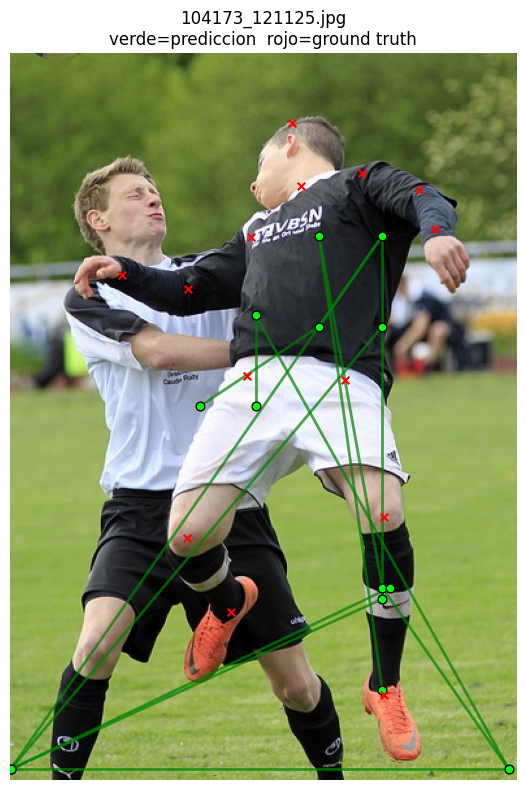

Error promedio: 220.1 px sobre 14 keypoints (imagen de 390x560)


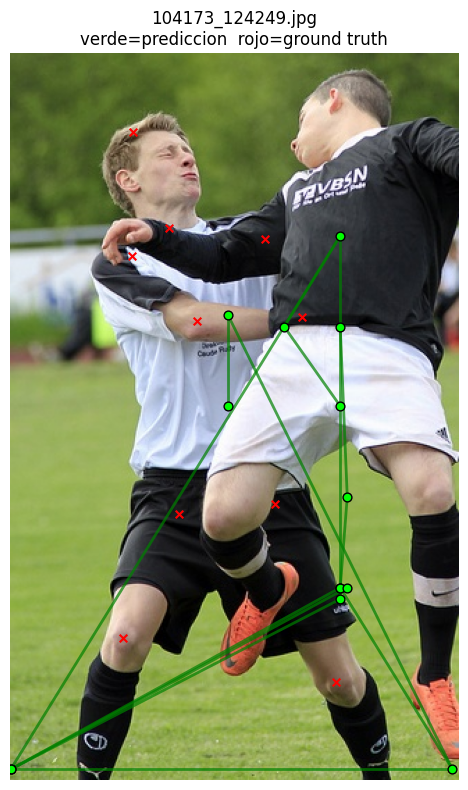

Error promedio: 192.3 px sobre 10 keypoints (imagen de 323x523)


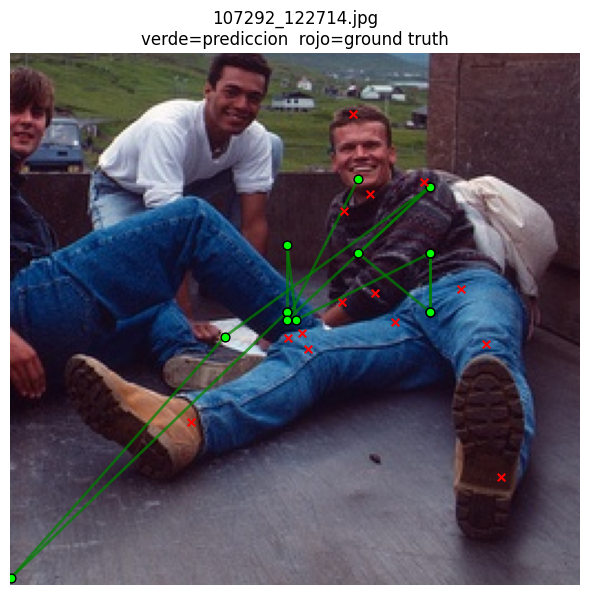

Error promedio: 59.7 px sobre 14 keypoints (imagen de 257x240)


In [16]:
# mirá varios ejemplos seguidos
for i in [1, 2, 3, 4, 5]:
    graficar_comparacion(i)

## 6. Ver los 14 heatmaps crudos de una imagen

Esto te deja ver la "forma" de la predicción antes de reducirla a un punto — útil para
diagnosticar: ¿el heatmap es una mancha concentrada y clara, o difuso y disperso por toda
la imagen? Un heatmap difuso indica que el modelo no está seguro de dónde está ese punto.

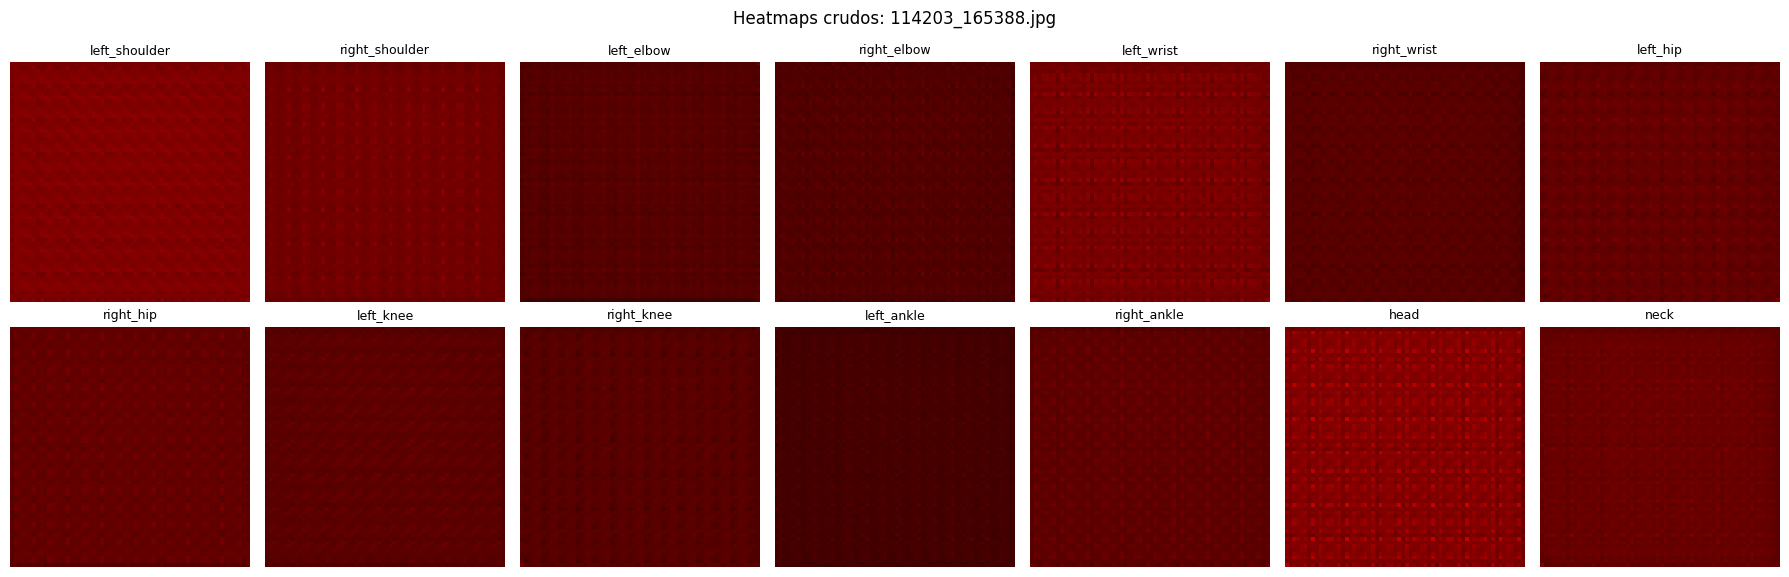

In [17]:
def ver_heatmaps_crudos(idx):
    img, heatmaps, gt, nombre = predecir(idx)
    fig, axes = plt.subplots(2, 7, figsize=(18, 6))
    for i, kp in enumerate(KP_NAMES):
        ax = axes[i // 7, i % 7]
        ax.imshow(heatmaps[i], cmap='hot', vmin=0, vmax=1)
        ax.set_title(kp, fontsize=9)
        ax.axis('off')
    plt.suptitle(f"Heatmaps crudos: {nombre}")
    plt.tight_layout()
    plt.show()

ver_heatmaps_crudos(0)

## 7. Error promedio sobre todo el set de validación

Un solo número resumen, útil para comparar entre corridas de tuneo (distinto sigma, distinto
backbone, etc.) sin tener que mirar imagen por imagen.

In [18]:
def error_promedio_dataset(n_max=None):
    n = len(df) if n_max is None else min(n_max, len(df))
    errores_por_kp = {kp: [] for kp in KP_NAMES}

    for idx in range(n):
        img, heatmaps, gt, _ = predecir(idx)
        pred = heatmaps_a_coords(heatmaps)
        w, h = img.size
        for kp in KP_NAMES:
            px, py, conf = pred[kp]
            gx, gy = gt[kp]
            if px is not None and 0.0 <= gx <= 1.0:
                err = np.sqrt(((px - gx) * w) ** 2 + ((py - gy) * h) ** 2)
                errores_por_kp[kp].append(err)

    print(f"Error promedio en pixeles por keypoint (sobre {n} imagenes):\n")
    todos = []
    for kp, errs in errores_por_kp.items():
        if errs:
            print(f"  {kp:16s}: {np.mean(errs):6.1f} px  (n={len(errs)})")
            todos.extend(errs)
    print(f"\n  {'PROMEDIO GLOBAL':16s}: {np.mean(todos):6.1f} px")
    return errores_por_kp


# n_max chico para que sea rapido; subilo cuando quieras el numero mas preciso
errores = error_promedio_dataset(n_max=50)

Error promedio en pixeles por keypoint (sobre 50 imagenes):

  left_shoulder   :  304.5 px  (n=47)
  right_shoulder  :   81.4 px  (n=49)
  left_elbow      :  115.2 px  (n=40)
  right_elbow     :   82.3 px  (n=48)
  left_wrist      :  102.2 px  (n=37)
  right_wrist     :  112.4 px  (n=45)
  left_hip        :  153.9 px  (n=44)
  right_hip       :  131.3 px  (n=46)
  left_knee       :  172.8 px  (n=41)
  right_knee      :  189.4 px  (n=43)
  left_ankle      :  186.3 px  (n=37)
  right_ankle     :  230.0 px  (n=36)
  head            :  208.0 px  (n=49)
  neck            :  353.6 px  (n=49)

  PROMEDIO GLOBAL :  174.2 px


## 8. Próximos pasos de tuneo

Con esto ya podés ver:
- **Qué keypoints fallan más** (la tabla de la celda anterior) — si por ejemplo `left_wrist`/`right_wrist`
  tienen error mucho más alto que `head`/`neck`, tiene sentido: las muñecas se mueven más y se
  ocluyen más seguido, así que es esperable que sean más difíciles.
- **Si el heatmap es nítido o difuso** (sección 6) — heatmaps muy difusos en epochs tempranos son
  normales; si siguen difusos después de entrenar más, puede valer la pena bajar `sigma` (heatmap
  más concentrado, señal de entrenamiento más exigente) o entrenar más epochs.

Para iterar el tuneo (sigma, backbone, lr, batch como charlamos antes):
1. Volvé a `entrenar_modelo_b.py` (o `entrenar_modelo_b_timm.py` si querés probar otros backbones)
2. Corré con la config nueva, guardando a un `.pth` con nombre distinto
3. Cambiá `RUTA_MODELO` en la celda 3 de este notebook al nuevo archivo
4. Volvé a correr `error_promedio_dataset()` y compará el número global contra esta corrida